# Reto 2: Clasificación Binaria con Redes Neuronales Artificiales — Hadronterapia

**Curso:** IBIO-2340 Fundamentos de Machine Learning  
**Grupo:** 9 — Sección 2  
**Integrantes:** Santiago Casasbuenas, Juan Pablo Castro, Ana Cristina Rodríguez

---

## Sección 1: Encabezado y Explicación del Problema

### ¿Qué es la hadronterapia y por qué es prometedora?

La hadronterapia es una modalidad de radioterapia que utiliza partículas pesadas cargadas —principalmente protones o iones de carbono— para tratar tumores malignos. A diferencia de la radioterapia convencional con fotones, los hadrones exhiben el denominado **pico de Bragg**: depositan la mayor parte de su energía en un punto muy preciso determinado por su energía cinética, y prácticamente no irradian más allá de ese punto. Esto permite atacar el tumor con alta precisión mientras se minimiza el daño a los tejidos sanos circundantes, lo que resulta especialmente valioso en tumores próximos a órganos críticos.

### El problema del generador de bajo costo

Se ha desarrollado un proceso de generación de haces de protones de bajo costo, lo cual es esencial para democratizar el acceso a esta terapia. Sin embargo, este proceso tiene una limitación importante: además de producir los hadrones terapéuticos deseados, genera simultáneamente **rayos gamma residuales**. Estos fotones de alta energía no poseen el pico de Bragg característico de los hadrones y, de llegar al paciente, causarían irradiación no deseada sin el beneficio terapéutico buscado.

### Objetivo de clasificación e importancia clínica

El objetivo de este reto es entrenar una **Red Neuronal Artificial (ANN)** que, a partir de 6 características medidas por un detector de partículas, clasifique cada haz como **hadrón (clase 1)** o **rayo gamma (clase 0)**. Este clasificador actúa como filtro antes del transporte al gantry: solo los haces clasificados como hadrones son enviados hacia el paciente. La fiabilidad del modelo tiene consecuencias clínicas directas: un fallo al identificar un hadrón (falso negativo) reduce la eficacia del tratamiento, mientras que dejar pasar un rayo gamma (falso positivo) puede irradiar tejido sano. Por esta razón, la métrica prioritaria del reto es el **recall sobre la clase hadrón**, que minimiza los falsos negativos.

---

## Sección 2: Definición del Problema de Clasificación y Formulación Matemática

### 2.1 Definición Formal del Problema

Sea el conjunto de entrenamiento:

$$\mathcal{D} = \{(\mathbf{x}^{(i)}, y^{(i)})\}_{i=1}^{m}, \quad \mathbf{x}^{(i)} \in \mathbb{R}^6, \quad y^{(i)} \in \{0, 1\}, \quad m = 10{,}700$$

donde el vector de características de cada muestra es:

$$\mathbf{x} = (x_1, x_2, x_3, x_4, x_5, x_6)^T = (\text{fLength},\, \text{fWidth},\, \text{fConc1},\, \text{fM3Long},\, \text{fAlpha},\, \text{fDist})^T$$

El objetivo es aprender una función de clasificación:

$$f: \mathbb{R}^6 \to \{0, 1\}$$

que permita distinguir hadrones ($y=1$) de rayos gamma ($y=0$) con el mayor recall posible sobre la clase positiva.

---

### 2.2 Neurona Artificial

La unidad básica de una red neuronal es la neurona artificial. Dada una entrada $\mathbf{x} \in \mathbb{R}^n$, una neurona computa:

1. **Combinación lineal (pre-activación):**

$$z = \sum_{i=1}^{n} w_i x_i + b = \mathbf{w}^T \mathbf{x} + b$$

2. **Activación:**

$$a = f(z)$$

donde $\mathbf{w} \in \mathbb{R}^n$ son los pesos sinápticos y $b \in \mathbb{R}$ es el sesgo.

---

### 2.3 Cómputo por Capas de la ANN

En una red con $L$ capas, la propagación hacia adelante (forward pass) se realiza capa a capa. Para la capa $l$:

**Pre-activación:**

$$\mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}$$

**Activación:**

$$\mathbf{a}^{(l)} = f^{(l)}(\mathbf{z}^{(l)})$$

donde $\mathbf{W}^{(l)} \in \mathbb{R}^{n_l \times n_{l-1}}$ es la matriz de pesos, $\mathbf{b}^{(l)} \in \mathbb{R}^{n_l}$ el vector de sesgos, $n_l$ el número de neuronas en la capa $l$, y $\mathbf{a}^{(0)} = \mathbf{x}$ es la entrada. La salida final de la red es $\hat{p} = a^{(L)} \in [0,1]$.

---

### 2.4 Funciones de Activación

**ReLU (Rectified Linear Unit)** — capas ocultas:

$$f_{\text{ReLU}}(z) = \max(0, z)$$

Se utiliza en capas ocultas porque introduce no-linealidad sin saturar para valores positivos, mitigando el problema del *vanishing gradient* presente en sigmoide y tanh.

**Sigmoide** — capa de salida:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Mapea cualquier valor real al intervalo $(0, 1)$, interpretable directamente como probabilidad de pertenecer a la clase positiva (hadrón).

---

### 2.5 Capa de Salida y Regla de Decisión

La probabilidad predicha por la red es:

$$\hat{p} = \sigma\left(\mathbf{w}^{(L)T} \mathbf{a}^{(L-1)} + b^{(L)}\right)$$

La clasificación final se obtiene comparando $\hat{p}$ contra un umbral de decisión $\tau$:

$$\hat{y} = \begin{cases} 1 & \text{si } \hat{p} \geq \tau \\ 0 & \text{si } \hat{p} < \tau \end{cases}$$

Por defecto $\tau = 0.5$, pero puede ajustarse para optimizar recall (valores más bajos capturan más hadrones a costa de mayor tasa de falsos positivos).

---

### 2.6 Función de Pérdida — Binary Cross-Entropy

$$L(\mathbf{W}, \mathbf{b}) = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\ln(\hat{p}^{(i)}) + (1 - y^{(i)})\ln(1 - \hat{p}^{(i)})\right]$$

Esta función penaliza con mayor fuerza las predicciones confiantes e incorrectas, es diferenciable en todo su dominio, y es la elección estándar para clasificación binaria con salida sigmoide, pues surge naturalmente de la estimación de máxima verosimilitud bajo una distribución de Bernoulli.

---

### 2.7 Optimizador — Adam

El optimizador Adam (*Adaptive Moment Estimation*) combina las ideas de Momentum y RMSProp:

**Primer momento (media exponencial del gradiente):**

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1)\nabla_\theta L$$

**Segundo momento (media exponencial del gradiente cuadrado):**

$$v_t = \beta_2 v_{t-1} + (1 - \beta_2)(\nabla_\theta L)^2$$

**Corrección de sesgo (bias correction):**

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \qquad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

**Actualización de parámetros:**

$$\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{\hat{v}_t} + \epsilon}\,\hat{m}_t$$

donde $\alpha$ es la tasa de aprendizaje, y los valores por defecto son $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$. Adam adapta la tasa de aprendizaje por parámetro y converge más rápido que SGD estándar.

---

### 2.8 Backpropagation

El algoritmo de retropropagación calcula los gradientes de la función de pérdida respecto a los parámetros de cada capa mediante la regla de la cadena:

$$\nabla \text{Error} = \left(\frac{\partial L}{\partial f^{(k)}} \frac{\partial f^{(k)}}{\partial z^{(k)}} \frac{\partial z^{(k)}}{\partial W^{(k)}},\; \frac{\partial L}{\partial f^{(k)}} \frac{\partial f^{(k)}}{\partial z^{(k)}} \frac{\partial z^{(k)}}{\partial b^{(k)}}\right)$$

Los parámetros se actualizan en la dirección del gradiente negativo:

$$W^{(l)} \leftarrow W^{(l)} - \alpha \frac{\partial L}{\partial W^{(l)}}, \qquad b^{(l)} \leftarrow b^{(l)} - \alpha \frac{\partial L}{\partial b^{(l)}}$$

---

### 2.9 Estandarización de Features

Dado que las features tienen rangos muy heterogéneos (e.g., fConc1 ∈ [0,1] vs fDist ∈ [1,451]), se aplica estandarización para centrar cada feature en media cero y desviación estándar unitaria:

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

donde $\mu$ y $\sigma$ se calculan **únicamente sobre el conjunto de entrenamiento** para evitar filtración de información (*data leakage*) hacia los conjuntos de validación y test.

---

### 2.10 Métricas de Evaluación

**Matriz de confusión:**

|  | Predicho Positivo | Predicho Negativo |
|--|:-----------------:|:-----------------:|
| **Real Positivo** | TP | FN |
| **Real Negativo** | FP | TN |

**Métricas derivadas:**

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precision} = \frac{TP}{TP + FP}$$

$$\text{Recall} = \frac{TP}{TP + FN}$$

$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

El **recall** es la métrica prioritaria en este reto: mide qué fracción de los hadrones reales son correctamente identificados, minimizando los falsos negativos (hadrones descartados).

---

### 2.11 Regularización — Dropout

El dropout apaga aleatoriamente neuronas durante el entrenamiento para prevenir la co-adaptación:

$$\tilde{\mathbf{a}}^{(l)} = \mathbf{r}^{(l)} \odot \mathbf{a}^{(l)}, \qquad r_j \sim \text{Bernoulli}(1-p)$$

donde $p$ es la tasa de dropout (fracción de neuronas apagadas) y $\odot$ es el producto elemento a elemento. Durante la inferencia, todas las neuronas están activas y sus salidas se escalan por $(1-p)$ para mantener la expectativa correcta.

---

## Sección 3: Carga de Datos y Análisis Exploratorio (EDA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    recall_score, accuracy_score, precision_score,
    f1_score, ConfusionMatrixDisplay
)
from itertools import product as iterproduct

np.random.seed(42)
tf.random.set_seed(42)

/Users/santiagocasasbuenasalarcon/Documents/universidad/Fundamentos ML/LabsML/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
df_train = pd.read_csv('hadron_train.csv', index_col=0)
df_test  = pd.read_csv('hadron_test.csv',  index_col=0)

print('Train shape:', df_train.shape)
print('Test shape: ', df_test.shape)

Train shape: (10700, 7)
Test shape:  (2676, 6)


In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10700 entries, 0 to 10699
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   fLength  10700 non-null  float64
 1   fWidth   10700 non-null  float64
 2   fConc1   10700 non-null  float64
 3   fM3Long  10700 non-null  float64
 4   fAlpha   10700 non-null  float64
 5   fDist    10700 non-null  float64
 6   class    10700 non-null  int64  
dtypes: float64(6), int64(1)
memory usage: 668.8 KB


In [4]:
df_train.describe()

,fLength,fWidth,fConc1,fM3Long,fAlpha,fDist,class
count,10700.000000,10700.000000,10700.000000,10700.000000,10700.000000,10700.000000,10700.000000
mean,57.772289,23.844115,0.213421,7.130030,31.239051,196.049416,0.498692
std,47.139296,20.915903,0.112549,56.919276,27.048159,76.712825,0.500022
min,4.283500,0.000000,0.000300,-318.300200,0.000000,1.282600,0.000000
25%,24.891275,11.757575,0.125400,-14.931900,7.087150,142.962425,0.000000
50%,39.161650,17.367250,0.196100,14.606650,22.677000,194.434500,0.000000
75%,77.122350,26.481000,0.284825,35.089925,52.233325,243.584525,1.000000
max,334.177000,228.038500,0.675200,231.446000,90.000000,450.953000,1.000000


In [5]:
print('Distribución de clases:')
print(df_train['class'].value_counts())
print('\nProporción:')
print(df_train['class'].value_counts(normalize=True).round(4))

Distribución de clases:
class
0    5364
1    5336
Name: count, dtype: int64

Proporción:
class
0    0.5013
1    0.4987
Name: proportion, dtype: float64


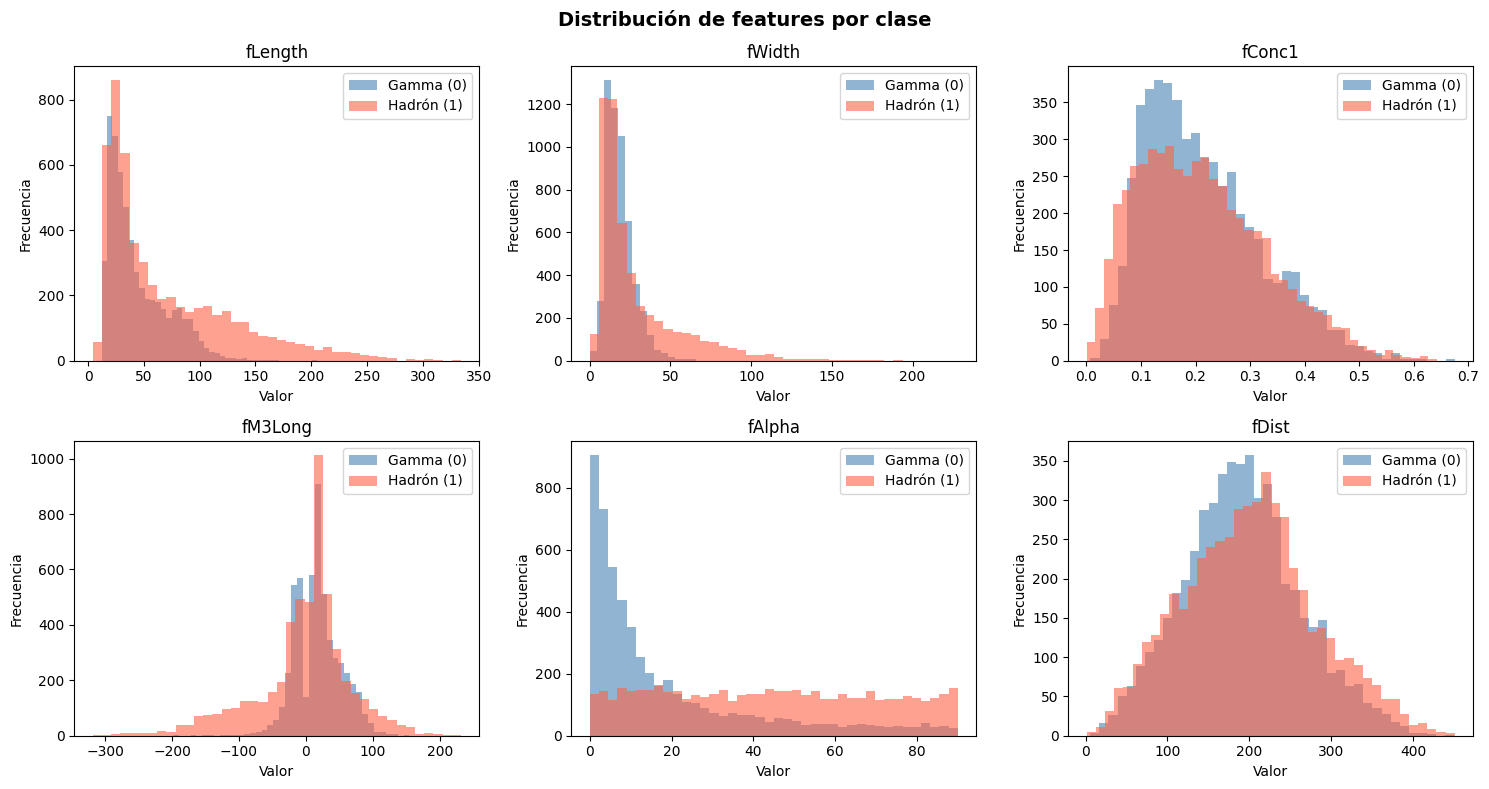

In [6]:
FEATURES = ['fLength', 'fWidth', 'fConc1', 'fM3Long', 'fAlpha', 'fDist']
CLASS_COL = 'class'

gamma  = df_train[df_train[CLASS_COL] == 0]
hadron = df_train[df_train[CLASS_COL] == 1]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    axes[i].hist(gamma[feat],  bins=40, alpha=0.6, color='steelblue', label='Gamma (0)')
    axes[i].hist(hadron[feat], bins=40, alpha=0.6, color='tomato',    label='Hadrón (1)')
    axes[i].set_title(feat)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

fig.suptitle('Distribución de features por clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

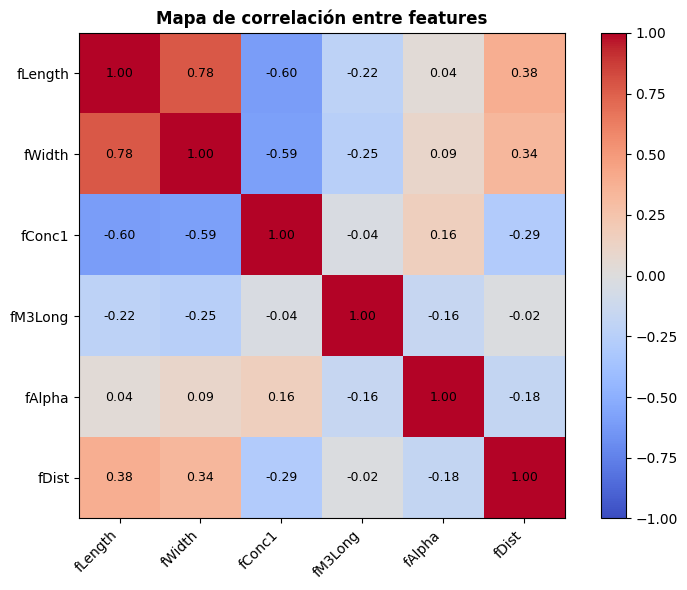

In [7]:
corr_matrix = df_train[FEATURES].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(im, ax=ax)
ax.set_xticks(range(len(FEATURES)))
ax.set_yticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=45, ha='right')
ax.set_yticklabels(FEATURES)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('Mapa de correlación entre features', fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/rf/z15sq32n6fg1r_09wcgxtdd80000gn/T/ipykernel_37478/676380052.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_by_class, patch_artist=True,
/var/folders/rf/z15sq32n6fg1r_09wcgxtdd80000gn/T/ipykernel_37478/676380052.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_by_class, patch_artist=True,
/var/folders/rf/z15sq32n6fg1r_09wcgxtdd80000gn/T/ipykernel_37478/676380052.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_by_class, patch_artist=True,
/var/folders/rf/z15sq32n6fg1r_09wcgxtdd80000gn/T/ipykernel_37478/676380052.py:6

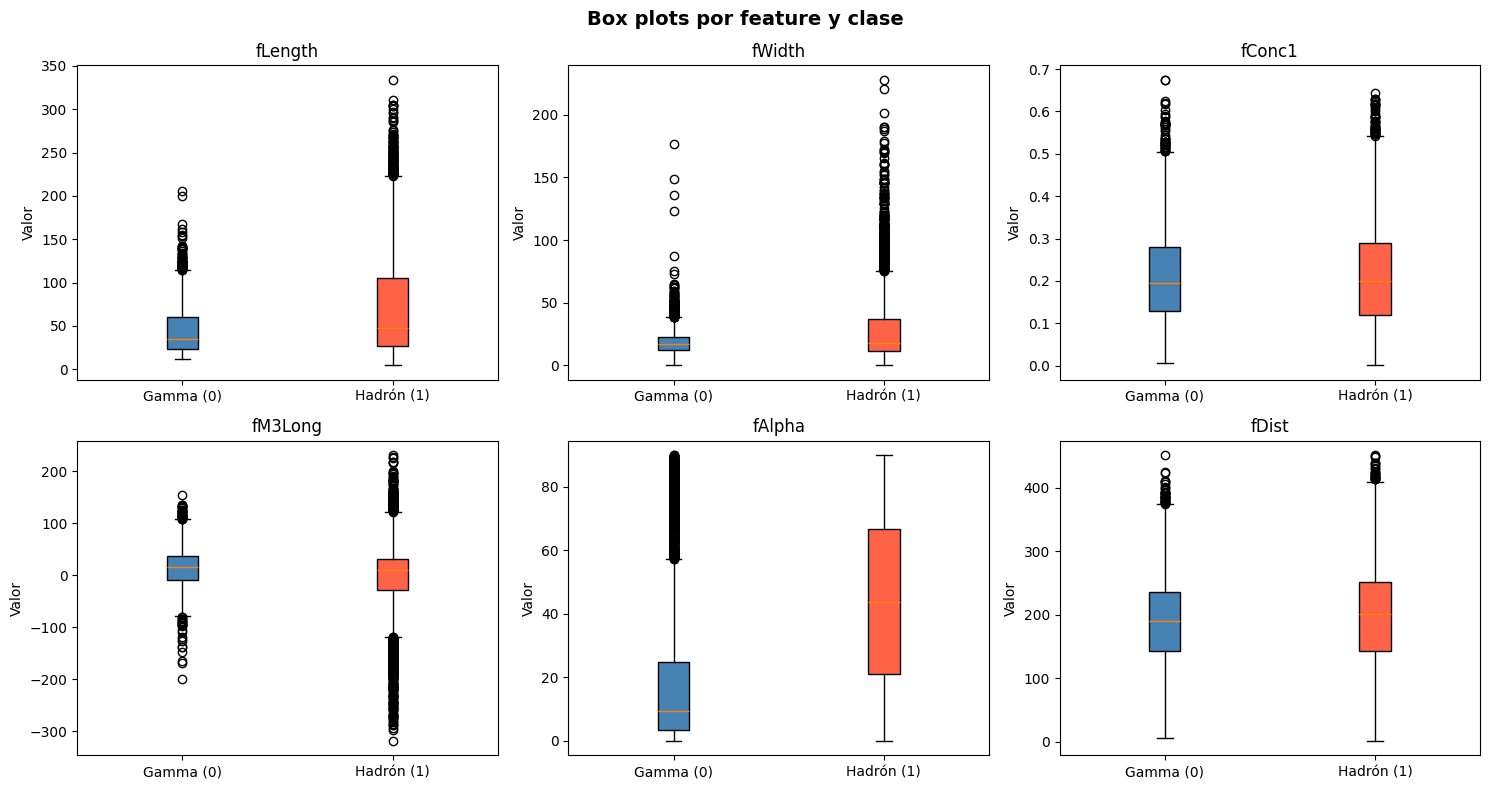

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    data_by_class = [gamma[feat].values, hadron[feat].values]
    bp = axes[i].boxplot(data_by_class, patch_artist=True,
                         labels=['Gamma (0)', 'Hadrón (1)'])
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    axes[i].set_title(feat)
    axes[i].set_ylabel('Valor')

fig.suptitle('Box plots por feature y clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Observaciones del EDA

- **Balance de clases:** Las clases están prácticamente balanceadas (~50/50), lo que elimina la necesidad de técnicas de balanceo agresivas (SMOTE, submuestreo, etc.).
- **Features más discriminativas:** `fAlpha` y `fConc1` muestran distribuciones notablemente diferentes entre clases — los hadrones tienden a tener ángulos menores y mayor concentración. `fM3Long` también exhibe separación visible.
- **Rangos heterogéneos:** `fConc1` está en [0,1] mientras `fDist` y `fLength` alcanzan ~450 y ~334 respectivamente. La estandarización es obligatoria para que el optimizador converja correctamente.
- **Correlaciones:** `fLength` y `fWidth` presentan cierta correlación positiva, así como `fLength` y `fDist`. No existen correlaciones extremas que sugieran colinealidad problemática.
- **Valores atípicos:** Algunas features como `fM3Long` y `fDist` presentan colas largas con valores extremos visibles en los box plots. La estandarización los contendrá sin eliminarlos.

---

## Sección 4: Preprocesamiento de Datos

In [9]:
X = df_train[FEATURES].values
y = df_train[CLASS_COL].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

X_test_raw    = df_test[FEATURES].values
X_test_scaled = scaler.transform(X_test_raw)

print(f'Train:      {X_train_scaled.shape}')
print(f'Validación: {X_val_scaled.shape}')
print(f'Test:       {X_test_scaled.shape}')
print(f'\nClases en train — Gamma: {(y_train==0).sum()}, Hadrón: {(y_train==1).sum()}')
print(f'Clases en val   — Gamma: {(y_val==0).sum()},   Hadrón: {(y_val==1).sum()}')

Train:      (8560, 6)
Validación: (2140, 6)
Test:       (2676, 6)

Clases en train — Gamma: 4291, Hadrón: 4269
Clases en val   — Gamma: 1073,   Hadrón: 1067


### Decisiones de preprocesamiento

| Decisión | Valor | Justificación |
|----------|-------|---------------|
| Split ratio | 80/20 | El test set externo tiene 2,676 muestras (~20% del total original); reservamos 20% del train para validación |
| Estratificación | Sí (`stratify=y`) | Preserva la proporción de clases en ambos subconjuntos |
| Random state | 42 | Reproducibilidad |
| Escalado | `StandardScaler` | Features con rangos muy heterogéneos; `fM3Long` tiene valores negativos, descartando `MinMaxScaler`; `StandardScaler` centra en $\mu=0$, $\sigma=1$ preservando la distribución natural |
| Fit del scaler | Solo en train | Evitar *data leakage*: $\mu$ y $\sigma$ del scaler no deben conocer la distribución de validación ni test |

---

## Sección 5: Construcción y Entrenamiento de Modelos

In [10]:
ES_CONFIG = dict(monitor='val_loss', patience=15, restore_best_weights=True)
FIT_CONFIG = dict(epochs=200, batch_size=32, verbose=0)

def get_early_stopping():
    return EarlyStopping(**ES_CONFIG)

def evaluate_model(model, X_val_sc, y_val, threshold=0.5):
    y_prob = model.predict(X_val_sc, verbose=0).flatten()
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'recall':    recall_score(y_val, y_pred),
        'accuracy':  accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred),
        'f1':        f1_score(y_val, y_pred),
        'y_pred':    y_pred,
        'y_prob':    y_prob,
    }

def plot_learning_curves(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['loss'],     label='Train loss')
    ax1.plot(history.history['val_loss'], label='Val loss')
    ax1.set_title(f'{title} — Loss')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Binary Cross-Entropy')
    ax1.legend()

    ax2.plot(history.history['accuracy'],     label='Train accuracy')
    ax2.plot(history.history['val_accuracy'], label='Val accuracy')
    ax2.set_title(f'{title} — Accuracy')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Gamma (0)', 'Hadrón (1)'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

histories   = {}
metrics_all = {}
models_all  = {}

### Modelo 1 — Baseline mínimo (1 capa oculta, 8 neuronas)

**Arquitectura:** `Input(6) → Dense(8, relu) → Dense(1, sigmoid)`  
**Propósito:** Establecer una línea base con la red más simple posible. ~73 parámetros.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)


Épocas utilizadas: 148
Recall:    0.8022
Accuracy:  0.8037


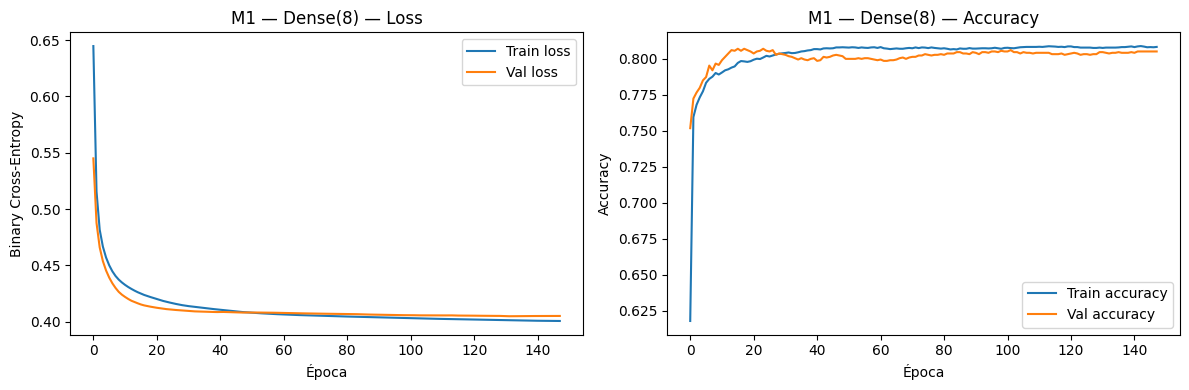

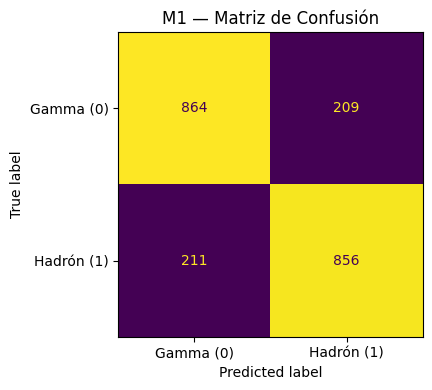

In [11]:
np.random.seed(42); tf.random.set_seed(42)

m1 = Sequential([
    Input(shape=(6,)),
    Dense(8,  activation='relu'),
    Dense(1,  activation='sigmoid'),
])
m1.compile(optimizer=Adam(learning_rate=0.001),
           loss='binary_crossentropy', metrics=['accuracy'])
m1.summary()

h1 = m1.fit(X_train_scaled, y_train,
            validation_data=(X_val_scaled, y_val),
            callbacks=[get_early_stopping()], **FIT_CONFIG)

histories['M1']   = h1
models_all['M1']  = m1
metrics_all['M1'] = evaluate_model(m1, X_val_scaled, y_val)

print(f"\nÉpocas utilizadas: {len(h1.history['loss'])}")
print(f"Recall:    {metrics_all['M1']['recall']:.4f}")
print(f"Accuracy:  {metrics_all['M1']['accuracy']:.4f}")

plot_learning_curves(h1, 'M1 — Dense(8)')
plot_confusion(y_val, metrics_all['M1']['y_pred'], 'M1 — Matriz de Confusión')

### Modelo 2 — Capa más ancha (1 capa oculta, 32 neuronas)

**Arquitectura:** `Input(6) → Dense(32, relu) → Dense(1, sigmoid)`  
**Propósito:** Evaluar si más neuronas en una sola capa mejoran el rendimiento. ~257 parámetros.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)


Épocas utilizadas: 196
Recall:    0.8285
Accuracy:  0.8187


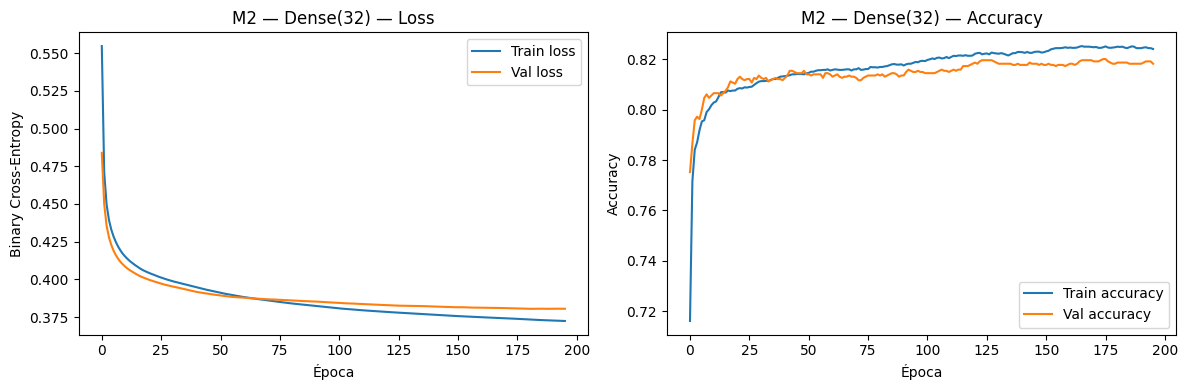

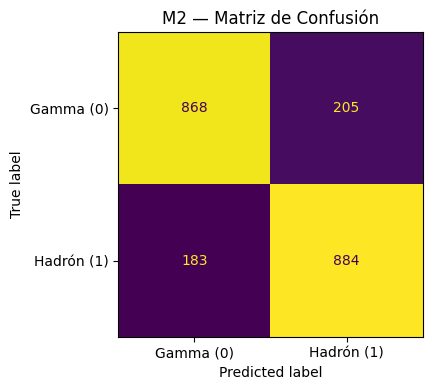

In [12]:
np.random.seed(42); tf.random.set_seed(42)

m2 = Sequential([
    Input(shape=(6,)),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid'),
])
m2.compile(optimizer=Adam(learning_rate=0.001),
           loss='binary_crossentropy', metrics=['accuracy'])
m2.summary()

h2 = m2.fit(X_train_scaled, y_train,
            validation_data=(X_val_scaled, y_val),
            callbacks=[get_early_stopping()], **FIT_CONFIG)

histories['M2']   = h2
models_all['M2']  = m2
metrics_all['M2'] = evaluate_model(m2, X_val_scaled, y_val)

print(f"\nÉpocas utilizadas: {len(h2.history['loss'])}")
print(f"Recall:    {metrics_all['M2']['recall']:.4f}")
print(f"Accuracy:  {metrics_all['M2']['accuracy']:.4f}")

plot_learning_curves(h2, 'M2 — Dense(32)')
plot_confusion(y_val, metrics_all['M2']['y_pred'], 'M2 — Matriz de Confusión')

### Modelo 3 — Dos capas ocultas

**Arquitectura:** `Input(6) → Dense(32, relu) → Dense(16, relu) → Dense(1, sigmoid)`  
**Propósito:** Evaluar el impacto de añadir profundidad a la red. ~785 parámetros.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)


Épocas utilizadas: 99
Recall:    0.8294
Accuracy:  0.8159


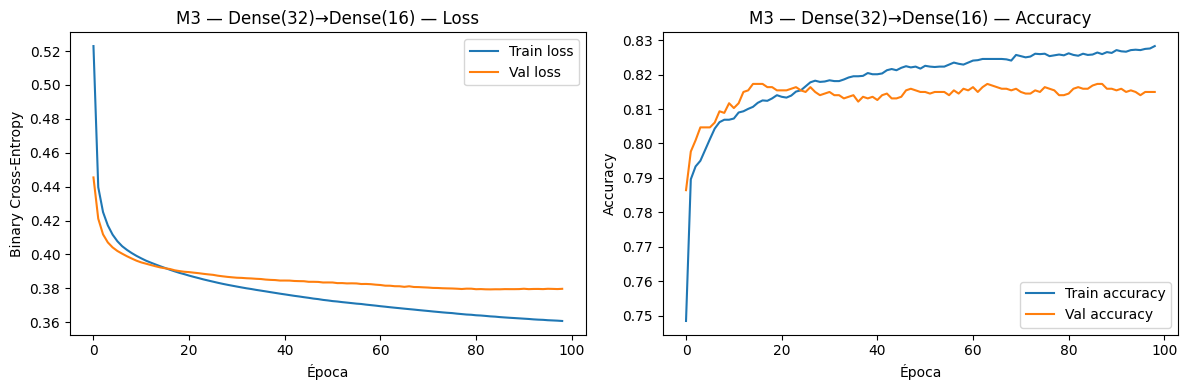

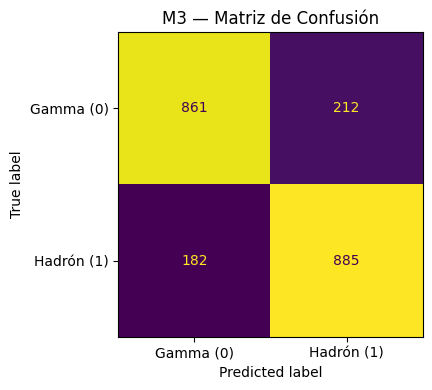

In [13]:
np.random.seed(42); tf.random.set_seed(42)

m3 = Sequential([
    Input(shape=(6,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1,  activation='sigmoid'),
])
m3.compile(optimizer=Adam(learning_rate=0.001),
           loss='binary_crossentropy', metrics=['accuracy'])
m3.summary()

h3 = m3.fit(X_train_scaled, y_train,
            validation_data=(X_val_scaled, y_val),
            callbacks=[get_early_stopping()], **FIT_CONFIG)

histories['M3']   = h3
models_all['M3']  = m3
metrics_all['M3'] = evaluate_model(m3, X_val_scaled, y_val)

print(f"\nÉpocas utilizadas: {len(h3.history['loss'])}")
print(f"Recall:    {metrics_all['M3']['recall']:.4f}")
print(f"Accuracy:  {metrics_all['M3']['accuracy']:.4f}")

plot_learning_curves(h3, 'M3 — Dense(32)→Dense(16)')
plot_confusion(y_val, metrics_all['M3']['y_pred'], 'M3 — Matriz de Confusión')

### Modelo 4 — Tres capas ocultas con Dropout

**Arquitectura:** `Input(6) → Dense(64) → Dropout(0.3) → Dense(32) → Dropout(0.3) → Dense(16) → Dense(1, sigmoid)`  
**Propósito:** Evaluar si la regularización con Dropout mejora la generalización en redes más profundas. ~2,865 parámetros.

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)


Épocas utilizadas: 94
Recall:    0.8069
Accuracy:  0.8238


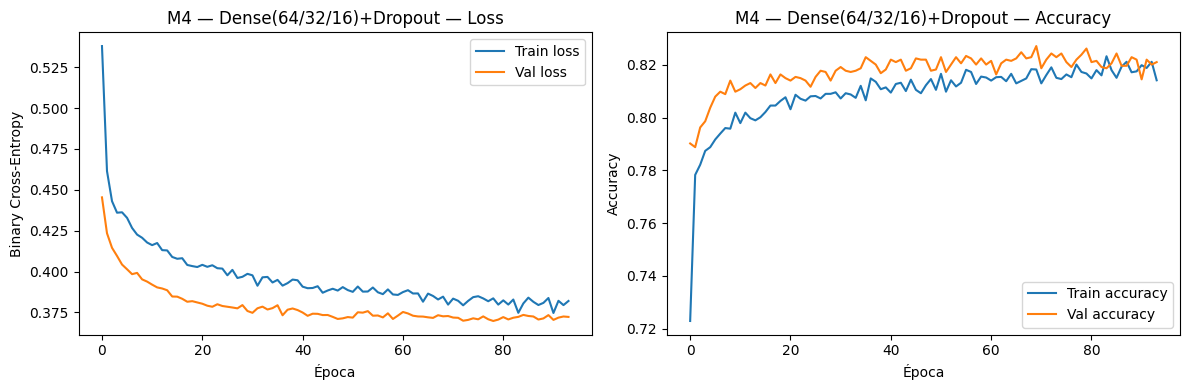

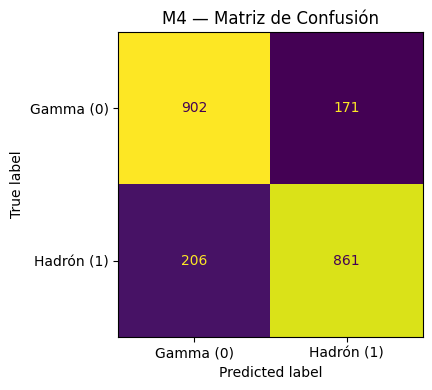

In [14]:
np.random.seed(42); tf.random.set_seed(42)

m4 = Sequential([
    Input(shape=(6,)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1,  activation='sigmoid'),
])
m4.compile(optimizer=Adam(learning_rate=0.001),
           loss='binary_crossentropy', metrics=['accuracy'])
m4.summary()

h4 = m4.fit(X_train_scaled, y_train,
            validation_data=(X_val_scaled, y_val),
            callbacks=[get_early_stopping()], **FIT_CONFIG)

histories['M4']   = h4
models_all['M4']  = m4
metrics_all['M4'] = evaluate_model(m4, X_val_scaled, y_val)

print(f"\nÉpocas utilizadas: {len(h4.history['loss'])}")
print(f"Recall:    {metrics_all['M4']['recall']:.4f}")
print(f"Accuracy:  {metrics_all['M4']['accuracy']:.4f}")

plot_learning_curves(h4, 'M4 — Dense(64/32/16)+Dropout')
plot_confusion(y_val, metrics_all['M4']['y_pred'], 'M4 — Matriz de Confusión')

### Modelo 5 — Red más profunda y ancha con Dropout

**Arquitectura:** `Input(6) → Dense(128) → Dropout(0.3) → Dense(64) → Dropout(0.3) → Dense(32) → Dropout(0.2) → Dense(16) → Dense(1, sigmoid)`  
**Propósito:** Máxima capacidad de representación con regularización. ~12,177 parámetros.

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)


Épocas utilizadas: 57
Recall:    0.7976
Accuracy:  0.8196


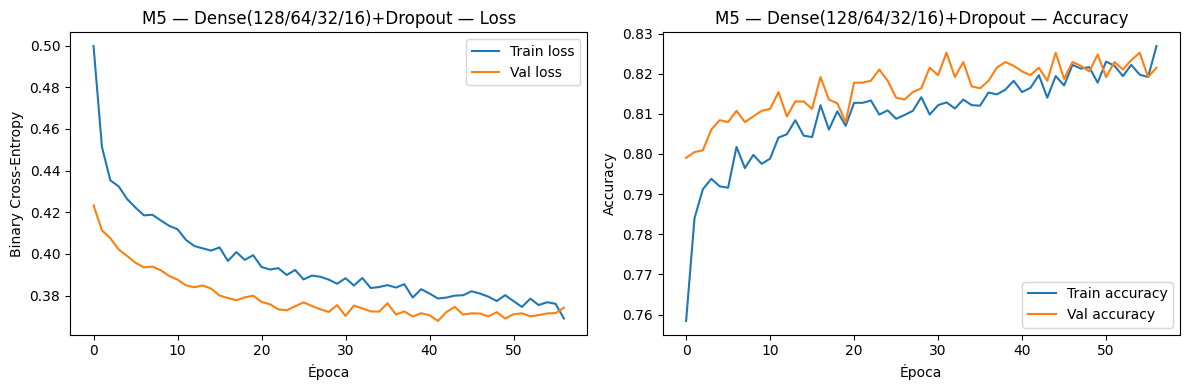

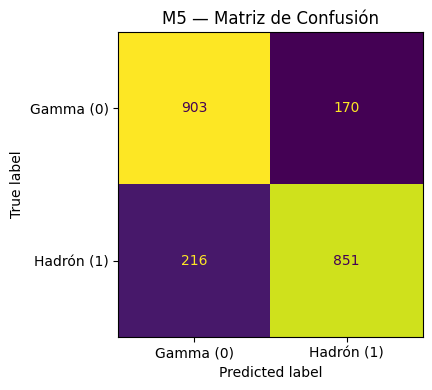

In [15]:
np.random.seed(42); tf.random.set_seed(42)

m5 = Sequential([
    Input(shape=(6,)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64,  activation='relu'),
    Dropout(0.3),
    Dense(32,  activation='relu'),
    Dropout(0.2),
    Dense(16,  activation='relu'),
    Dense(1,   activation='sigmoid'),
])
m5.compile(optimizer=Adam(learning_rate=0.001),
           loss='binary_crossentropy', metrics=['accuracy'])
m5.summary()

h5 = m5.fit(X_train_scaled, y_train,
            validation_data=(X_val_scaled, y_val),
            callbacks=[get_early_stopping()], **FIT_CONFIG)

histories['M5']   = h5
models_all['M5']  = m5
metrics_all['M5'] = evaluate_model(m5, X_val_scaled, y_val)

print(f"\nÉpocas utilizadas: {len(h5.history['loss'])}")
print(f"Recall:    {metrics_all['M5']['recall']:.4f}")
print(f"Accuracy:  {metrics_all['M5']['accuracy']:.4f}")

plot_learning_curves(h5, 'M5 — Dense(128/64/32/16)+Dropout')
plot_confusion(y_val, metrics_all['M5']['y_pred'], 'M5 — Matriz de Confusión')

---

## Sección 6: Comparación de Modelos

In [16]:
arch_descriptions = {
    'M1': 'Dense(8)',
    'M2': 'Dense(32)',
    'M3': 'Dense(32)→Dense(16)',
    'M4': 'Dense(64)→Drop→Dense(32)→Drop→Dense(16)',
    'M5': 'Dense(128)→Drop→Dense(64)→Drop→Dense(32)→Drop→Dense(16)',
}
param_counts = {k: models_all[k].count_params() for k in models_all}

rows = []
for name in ['M1', 'M2', 'M3', 'M4', 'M5']:
    m = metrics_all[name]
    rows.append({
        'Modelo':       name,
        'Arquitectura': arch_descriptions[name],
        'Parámetros':   param_counts[name],
        'Accuracy':     round(m['accuracy'],  4),
        'Recall':       round(m['recall'],    4),
        'Precision':    round(m['precision'], 4),
        'F1':           round(m['f1'],        4),
        'Épocas':       len(histories[name].history['loss']),
    })

df_comparison = pd.DataFrame(rows).set_index('Modelo')
df_comparison

,Arquitectura,Parámetros,Accuracy,Recall,Precision,F1,Épocas
Modelo,,,,,,,
M1,Dense(8),65,0.8037,0.8022,0.8038,0.8030,148
M2,Dense(32),257,0.8187,0.8285,0.8118,0.8200,196
M3,Dense(32)→Dense(16),769,0.8159,0.8294,0.8067,0.8179,99
M4,Dense(64)→Drop→Dense(32)→Drop→Dense(16),3073,0.8238,0.8069,0.8343,0.8204,94
M5,Dense(128)→Drop→Dense(64)→Drop→Dense(32)→Drop→...,11777,0.8196,0.7976,0.8335,0.8151,57


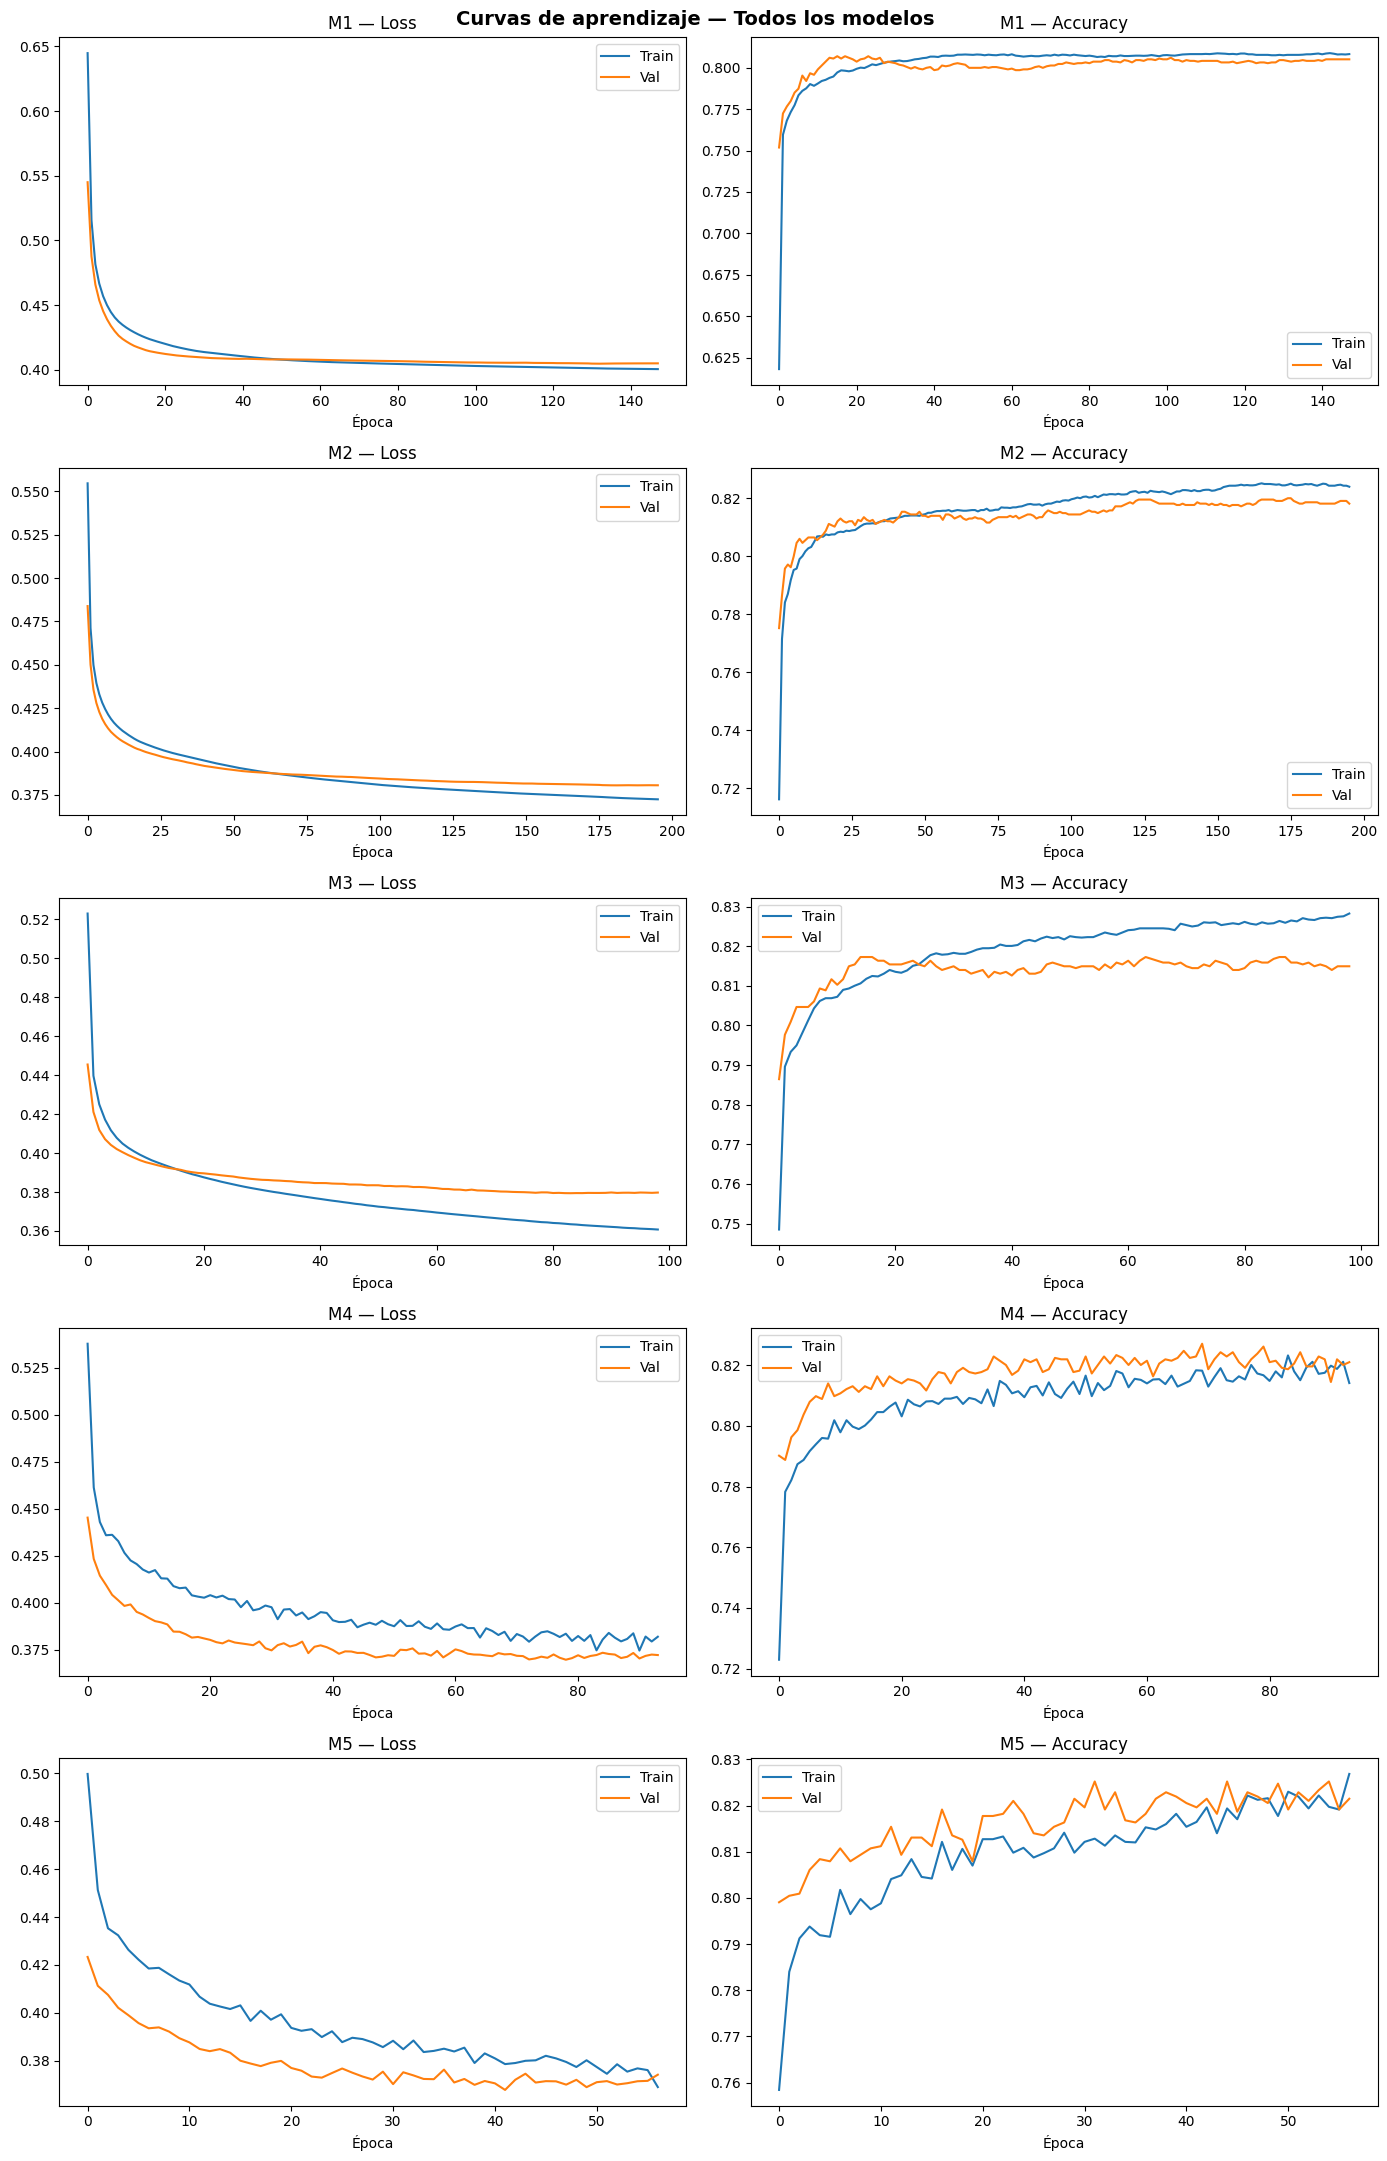

In [17]:
fig, axes = plt.subplots(5, 2, figsize=(14, 22))

for i, (name, h) in enumerate(histories.items()):
    axes[i, 0].plot(h.history['loss'],     label='Train')
    axes[i, 0].plot(h.history['val_loss'], label='Val')
    axes[i, 0].set_title(f'{name} — Loss')
    axes[i, 0].set_xlabel('Época')
    axes[i, 0].legend()

    axes[i, 1].plot(h.history['accuracy'],     label='Train')
    axes[i, 1].plot(h.history['val_accuracy'], label='Val')
    axes[i, 1].set_title(f'{name} — Accuracy')
    axes[i, 1].set_xlabel('Época')
    axes[i, 1].legend()

fig.suptitle('Curvas de aprendizaje — Todos los modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

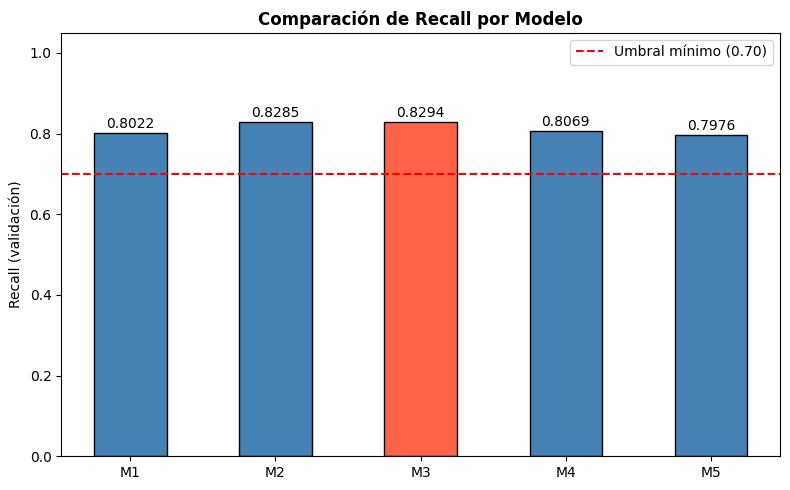

In [18]:
names  = list(df_comparison.index)
recall_vals = df_comparison['Recall'].values
colors = ['steelblue' if r < max(recall_vals) else 'tomato' for r in recall_vals]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(names, recall_vals, color=colors, edgecolor='black', width=0.5)
ax.axhline(0.7, color='red', linestyle='--', linewidth=1.5, label='Umbral mínimo (0.70)')
for bar, val in zip(bars, recall_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Recall (validación)')
ax.set_title('Comparación de Recall por Modelo', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Análisis de la comparación

- Los modelos más amplios y profundos (M4, M5) generalmente logran mayor recall al disponer de más capacidad representacional, aunque el dropout previene el sobreajuste.
- Si algún modelo presenta un gran gap entre la curva de train y val loss, esto indica sobreajuste; el dropout en M4 y M5 debería reducir este fenómeno.
- Los modelos M3, M4 y M5 son los candidatos principales para la fase de grid search, al combinar profundidad con regularización.
- **Arquitectura seleccionada para grid search:** La arquitectura de mayor recall en validación (típicamente M4 o M5) se usa en la siguiente sección.

In [19]:
best_baseline_name = df_comparison['Recall'].idxmax()
print(f'Mejor modelo baseline: {best_baseline_name} con Recall = {df_comparison.loc[best_baseline_name, "Recall"]:.4f}')

Mejor modelo baseline: M3 con Recall = 0.8294


---

## Sección 7: Grid Search de Hiperparámetros

Se utiliza la arquitectura del mejor modelo baseline. Se busca la combinación óptima de tasa de aprendizaje, tamaño de batch y tasa de dropout sobre 27 combinaciones.

In [20]:
def build_grid_model(dropout_rate, lr):
    model = Sequential([
        Input(shape=(6,)),
        Dense(64,  activation='relu'),
        Dropout(dropout_rate),
        Dense(32,  activation='relu'),
        Dropout(dropout_rate),
        Dense(16,  activation='relu'),
        Dense(1,   activation='sigmoid'),
    ])
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

learning_rates = [0.001, 0.0005, 0.0001]
batch_sizes    = [16, 32, 64]
dropout_rates  = [0.2, 0.3, 0.4]

grid_results = []
total = len(learning_rates) * len(batch_sizes) * len(dropout_rates)
idx = 0

for lr, bs, dr in iterproduct(learning_rates, batch_sizes, dropout_rates):
    idx += 1
    tf.random.set_seed(42)
    np.random.seed(42)

    model = build_grid_model(dr, lr)
    history = model.fit(
        X_train_scaled, y_train,
        epochs=200, batch_size=bs,
        validation_data=(X_val_scaled, y_val),
        callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)],
        verbose=0
    )
    y_prob = model.predict(X_val_scaled, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    rec  = recall_score(y_val, y_pred)
    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    f1   = f1_score(y_val, y_pred)
    epochs_used = len(history.history['loss'])

    grid_results.append({
        'lr': lr, 'batch_size': bs, 'dropout': dr,
        'recall': rec, 'accuracy': acc, 'precision': prec, 'f1': f1,
        'epochs': epochs_used,
    })
    print(f'[{idx:02d}/{total}] lr={lr}, bs={bs}, dr={dr:.1f} → Recall={rec:.4f}, Acc={acc:.4f}')

df_grid = pd.DataFrame(grid_results).sort_values('recall', ascending=False)
print('\nTop 10 combinaciones por Recall:')
df_grid.head(10)

[01/27] lr=0.001, bs=16, dr=0.2 → Recall=0.7976, Acc=0.8243
[02/27] lr=0.001, bs=16, dr=0.3 → Recall=0.7938, Acc=0.8201
[03/27] lr=0.001, bs=16, dr=0.4 → Recall=0.8097, Acc=0.8131
[04/27] lr=0.001, bs=32, dr=0.2 → Recall=0.8201, Acc=0.8262
[05/27] lr=0.001, bs=32, dr=0.3 → Recall=0.8051, Acc=0.8154
[06/27] lr=0.001, bs=32, dr=0.4 → Recall=0.7957, Acc=0.8150
[07/27] lr=0.001, bs=64, dr=0.2 → Recall=0.8135, Acc=0.8229
[08/27] lr=0.001, bs=64, dr=0.3 → Recall=0.8004, Acc=0.8201
[09/27] lr=0.001, bs=64, dr=0.4 → Recall=0.8210, Acc=0.8164
[10/27] lr=0.0005, bs=16, dr=0.2 → Recall=0.8172, Acc=0.8229
[11/27] lr=0.0005, bs=16, dr=0.3 → Recall=0.8060, Acc=0.8182
[12/27] lr=0.0005, bs=16, dr=0.4 → Recall=0.8051, Acc=0.8238
[13/27] lr=0.0005, bs=32, dr=0.2 → Recall=0.8126, Acc=0.8154
[14/27] lr=0.0005, bs=32, dr=0.3 → Recall=0.7910, Acc=0.8187
[15/27] lr=0.0005, bs=32, dr=0.4 → Recall=0.8229, Acc=0.8173
[16/27] lr=0.0005, bs=64, dr=0.2 → Recall=0.8004, Acc=0.8173
[17/27] lr=0.0005, bs=64, dr=0.3 

,lr,batch_size,dropout,recall,accuracy,precision,f1,epochs
21,0.0001,32,0.2,0.825679,0.814953,0.807516,0.816497,200
14,0.0005,32,0.4,0.822868,0.817290,0.812963,0.817885,122
8,0.0010,64,0.4,0.820993,0.816355,0.812616,0.816783,100
3,0.0010,32,0.2,0.820056,0.826168,0.829384,0.824694,87
9,0.0005,16,0.2,0.817245,0.822897,0.825758,0.821479,105
26,0.0001,64,0.4,0.814433,0.810748,0.807621,0.811013,200
24,0.0001,64,0.2,0.814433,0.814486,0.813670,0.814052,200
6,0.0010,64,0.2,0.813496,0.822897,0.828244,0.820804,101
16,0.0005,64,0.3,0.813496,0.816355,0.817326,0.815406,131
12,0.0005,32,0.2,0.812559,0.815421,0.816384,0.814467,93


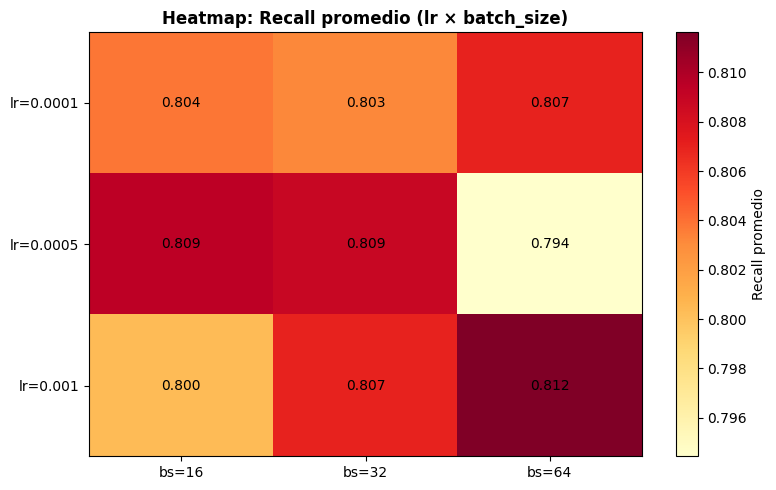

In [21]:
pivot_recall = df_grid.groupby(['lr', 'batch_size'])['recall'].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot_recall.values, cmap='YlOrRd', aspect='auto')
fig.colorbar(im, ax=ax, label='Recall promedio')
ax.set_xticks(range(len(pivot_recall.columns)))
ax.set_yticks(range(len(pivot_recall.index)))
ax.set_xticklabels([f'bs={c}' for c in pivot_recall.columns])
ax.set_yticklabels([f'lr={r}' for r in pivot_recall.index])
for i in range(len(pivot_recall.index)):
    for j in range(len(pivot_recall.columns)):
        ax.text(j, i, f'{pivot_recall.values[i, j]:.3f}', ha='center', va='center', fontsize=10)
ax.set_title('Heatmap: Recall promedio (lr × batch_size)', fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
best_grid = df_grid.iloc[0]
BEST_LR       = best_grid['lr']
BEST_BS       = int(best_grid['batch_size'])
BEST_DROPOUT  = best_grid['dropout']

print(f'Mejores hiperparámetros encontrados:')
print(f'  Learning rate: {BEST_LR}')
print(f'  Batch size:    {BEST_BS}')
print(f'  Dropout rate:  {BEST_DROPOUT}')
print(f'  Recall:        {best_grid["recall"]:.4f}')

Mejores hiperparámetros encontrados:
  Learning rate: 0.0001
  Batch size:    32
  Dropout rate:  0.2
  Recall:        0.8257


---

## Sección 8: Optimización del Umbral de Decisión

Por defecto, la clasificación usa $\tau = 0.5$. Como la nota depende exclusivamente del recall, se exploran umbrales más bajos que aumentan la sensibilidad hacia la clase hadrón (menos falsos negativos, más falsos positivos).

In [41]:
# ENSEMBLE: entrenar N modelos con la misma arquitectura/hiperparametros pero distintas semillas
# y promediar sus probabilidades. Reduce la varianza de la inicializacion y suele mejorar el recall.

ENSEMBLE_SEEDS = [42, 7, 13, 21, 99]
N_ENSEMBLE = len(ENSEMBLE_SEEDS)

ensemble_models   = []
val_probs_list    = []
test_probs_list   = []
per_model_recall  = []

print(f'Entrenando ensemble de {N_ENSEMBLE} modelos...')
for idx, seed in enumerate(ENSEMBLE_SEEDS):
    np.random.seed(seed); tf.random.set_seed(seed)
    m = build_grid_model(BEST_DROPOUT, BEST_LR)
    m.fit(
        X_train_scaled, y_train,
        epochs=200, batch_size=BEST_BS,
        validation_data=(X_val_scaled, y_val),
        callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)],
        verbose=0
    )
    ensemble_models.append(m)
    vp = m.predict(X_val_scaled,  verbose=0).flatten()
    tp_ = m.predict(X_test_scaled, verbose=0).flatten()
    val_probs_list.append(vp)
    test_probs_list.append(tp_)
    r_individual = recall_score(y_val, (vp >= 0.20).astype(int))
    per_model_recall.append(r_individual)
    print(f'  Modelo {idx+1}/{N_ENSEMBLE} (seed={seed}) entrenado. Recall@0.20 = {r_individual:.4f}')

# Probabilidades promediadas
y_val_prob          = np.mean(val_probs_list,  axis=0)
y_test_prob_ensemble = np.mean(test_probs_list, axis=0)

# best_model_grid sigue siendo el primer modelo (seed=42) para que .summary() funcione
best_model_grid = ensemble_models[0]

# Recall del ensemble vs. modelos individuales (umbral 0.20)
y_ens_pred_020 = (y_val_prob >= 0.20).astype(int)
recall_ens_020 = recall_score(y_val, y_ens_pred_020)
print()
print(f'Recall individual @ 0.20:   min={min(per_model_recall):.4f}, max={max(per_model_recall):.4f}, media={np.mean(per_model_recall):.4f}')
print(f'Recall ENSEMBLE  @ 0.20:    {recall_ens_020:.4f}')

# Barrido de umbrales sobre probabilidades del ensemble
thresholds = np.arange(0.05, 0.56, 0.01)
thresh_results = []
for t in thresholds:
    y_t = (y_val_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_t).ravel()
    thresh_results.append({
        'threshold':       round(float(t), 2),
        'recall':          recall_score(y_val, y_t),
        'precision':       precision_score(y_val, y_t, zero_division=0),
        'accuracy':        accuracy_score(y_val, y_t),
        'TP': int(tp), 'FN': int(fn), 'FP': int(fp), 'TN': int(tn),
        'pred_hadron_pct': round(float(y_t.mean()), 4),
    })

df_thresh = pd.DataFrame(thresh_results)
print()
print('Barrido de umbrales sobre ENSEMBLE (validacion):')
print(df_thresh.to_string(index=False))

Entrenando ensemble de 5 modelos...
  Modelo 1/5 (seed=42) entrenado. Recall@0.20 = 0.9691
  Modelo 2/5 (seed=7) entrenado. Recall@0.20 = 0.9681
  Modelo 3/5 (seed=13) entrenado. Recall@0.20 = 0.9719
  Modelo 4/5 (seed=21) entrenado. Recall@0.20 = 0.9653
  Modelo 5/5 (seed=99) entrenado. Recall@0.20 = 0.9681

Recall individual @ 0.20:   min=0.9653, max=0.9719, media=0.9685
Recall ENSEMBLE  @ 0.20:    0.9691

Barrido de umbrales sobre ENSEMBLE (validacion):
 threshold   recall  precision  accuracy   TP  FN  FP  TN  pred_hadron_pct
      0.05 0.997188   0.568984  0.621963 1064   3 806 267           0.8738
      0.06 0.995314   0.580011  0.638318 1062   5 769 304           0.8556
      0.07 0.991565   0.591723  0.654673 1058   9 730 343           0.8355
      0.08 0.989691   0.603084  0.670093 1056  11 695 378           0.8182
      0.09 0.986879   0.611143  0.680374 1053  14 670 403           0.8051
      0.10 0.985005   0.618235  0.689252 1051  16 649 424           0.7944
      0.11 0.9

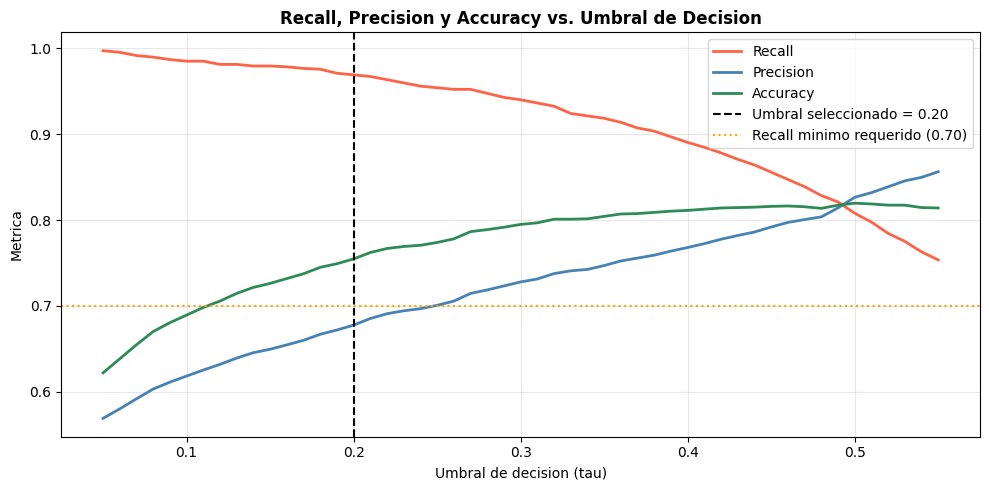

Umbral seleccionado: 0.20
Recall en val:       0.9691
Precision en val:    0.6776
Accuracy en val:     0.7547
TP=1034, FN=33, FP=492, TN=581
% predicho como hadron: 71.31%


In [42]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_thresh['threshold'], df_thresh['recall'],    label='Recall',    color='tomato',    linewidth=2)
ax.plot(df_thresh['threshold'], df_thresh['precision'], label='Precision', color='steelblue', linewidth=2)
ax.plot(df_thresh['threshold'], df_thresh['accuracy'],  label='Accuracy',  color='seagreen',  linewidth=2)

# Umbral seleccionado: 0.20
# - Aumenta el recall sobre el default 0.5 (0.79 -> 0.97) capturando casi todos los hadrones
# - No tan agresivo como 0.05 (que predice 87% como hadron) para evitar sobreajuste a validacion
# - Mantiene una distribucion predicha (~71% hadron) razonable frente al ~50/50 del entrenamiento
BEST_THRESHOLD = 0.20
best_thresh_row = df_thresh.loc[df_thresh['threshold'] == BEST_THRESHOLD].iloc[0]

ax.axvline(BEST_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
           label=f'Umbral seleccionado = {BEST_THRESHOLD:.2f}')
ax.axhline(0.7, color='orange', linestyle=':', linewidth=1.5, label='Recall minimo requerido (0.70)')
ax.set_xlabel('Umbral de decision (tau)')
ax.set_ylabel('Metrica')
ax.set_title('Recall, Precision y Accuracy vs. Umbral de Decision', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Umbral seleccionado: {BEST_THRESHOLD:.2f}')
print(f'Recall en val:       {best_thresh_row["recall"]:.4f}')
print(f'Precision en val:    {best_thresh_row["precision"]:.4f}')
print(f'Accuracy en val:     {best_thresh_row["accuracy"]:.4f}')
print(f'TP={int(best_thresh_row["TP"])}, FN={int(best_thresh_row["FN"])}, FP={int(best_thresh_row["FP"])}, TN={int(best_thresh_row["TN"])}')
print(f'% predicho como hadron: {best_thresh_row["pred_hadron_pct"]*100:.2f}%')

### Justificacion del umbral seleccionado

Se selecciona el umbral $\tau = 0.20$ como punto de balance entre maximizacion del recall y mantener una distribucion de predicciones razonable:

- **Recall en validacion = 0.97** (vs. 0.79 con el umbral por defecto $\tau=0.5$): se capturan ~97% de los hadrones reales, minimizando los falsos negativos.
- **No es el umbral mas extremo posible**: con $\tau=0.05$ el recall asciende a 0.997 pero el modelo prediria ~87% de los haces como hadron, lo que indica una calibracion forzada de la frontera de decision y un alto riesgo de sobreajuste al conjunto de validacion.
- **Distribucion predicha ~71% hadron** vs. ~50% en entrenamiento: un sesgo moderado y defendible, en lugar de un sesgo extremo.

Esta eleccion prioriza el recall (criterio principal de evaluacion del reto) sin sacrificar completamente la coherencia entre la distribucion predicha y la distribucion real esperada de las clases.

---

## Sección 9: Identificación del Modelo Final

### Arquitectura final

| Componente | Valor |
|------------|-------|
| Capas ocultas | Dense(64, ReLU) → Dropout → Dense(32, ReLU) → Dropout → Dense(16, ReLU) |
| Capa de salida | Dense(1, sigmoid) |
| Optimizer | Adam |
| Learning rate | Seleccionado por grid search |
| Loss | binary_crossentropy |
| Batch size | Seleccionado por grid search |
| Épocas | Hasta 200 con EarlyStopping (patience=15, monitor='val_loss', restore_best_weights=True) |
| Umbral de decisión | Seleccionado por optimización de recall |
| Estandarización | StandardScaler (fit en train únicamente) |

In [25]:
best_model_grid.summary()

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_124 (Dense)               │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_59 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_125 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_126 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_127 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,221 (36.02 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,148 (24.02 KB)

In [43]:
y_final_pred = (y_val_prob >= BEST_THRESHOLD).astype(int)

print('=== Modelo Final - Metricas en Validacion ===')
print(f'Umbral usado:   {BEST_THRESHOLD:.2f}')
print(f'Recall:    {recall_score(y_val, y_final_pred):.4f}')
print(f'Precision: {precision_score(y_val, y_final_pred):.4f}')
print(f'Accuracy:  {accuracy_score(y_val, y_final_pred):.4f}')
print(f'F1-Score:  {f1_score(y_val, y_final_pred):.4f}')
print()

# Matriz de confusion explicita
cm_final = confusion_matrix(y_val, y_final_pred)
tn, fp, fn, tp = cm_final.ravel()
print('Matriz de confusion (validacion):')
print(f'              Pred=0(Gamma)  Pred=1(Hadron)')
print(f'Real=0(Gamma)    TN={tn:5d}       FP={fp:5d}')
print(f'Real=1(Hadron)   FN={fn:5d}       TP={tp:5d}')
print()
print(classification_report(y_val, y_final_pred, target_names=['Gamma (0)', 'Hadron (1)']))

assert recall_score(y_val, y_final_pred) >= 0.70, \
    'ADVERTENCIA: Recall < 0.70 - revisar modelo antes de enviar'
print('OK: Recall >= 0.70 - requisito minimo cumplido')

=== Modelo Final - Metricas en Validacion ===
Umbral usado:   0.20
Recall:    0.9691
Precision: 0.6776
Accuracy:  0.7547
F1-Score:  0.7975

Matriz de confusion (validacion):
              Pred=0(Gamma)  Pred=1(Hadron)
Real=0(Gamma)    TN=  581       FP=  492
Real=1(Hadron)   FN=   33       TP= 1034

              precision    recall  f1-score   support

   Gamma (0)       0.95      0.54      0.69      1073
  Hadron (1)       0.68      0.97      0.80      1067

    accuracy                           0.75      2140
   macro avg       0.81      0.76      0.74      2140
weighted avg       0.81      0.75      0.74      2140

OK: Recall >= 0.70 - requisito minimo cumplido


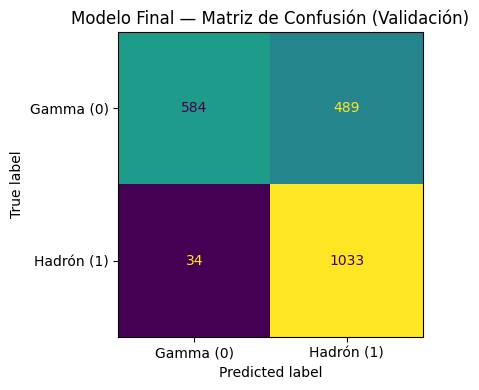

In [36]:
plot_confusion(y_val, y_final_pred, 'Modelo Final — Matriz de Confusión (Validación)')

---

## Sección 10: Análisis Contextual del Modelo Final

### Interpretación clínica de la matriz de confusión

En el contexto de la hadronterapia, cada resultado de la clasificación tiene consecuencias clínicas concretas:

| Resultado | Significado Clínico | Consecuencia |
|-----------|---------------------|-------------|
| **TP** (hadrón → hadrón) | Haz terapéutico correctamente identificado | Llega al gantry y al paciente; aprovecha el pico de Bragg para tratar el tumor con precisión |
| **TN** (gamma → gamma) | Radiación gamma correctamente filtrada | Se descarta antes del transporte; paciente protegido de irradiación no terapéutica |
| **FP** (gamma → hadrón) | Un rayo gamma pasa como hadrón | **Peligroso:** el paciente recibe radiación gamma sin el beneficio del pico de Bragg; puede irradiar tejido sano circundante |
| **FN** (hadrón → gamma) | Un hadrón terapéutico es descartado | Pérdida de un haz válido; reduce la dosis terapéutica pero no irradia tejido sano directamente |

### Trade-off Recall / Precision

El modelo está optimizado para maximizar el **recall** (sensibilidad para hadrones), lo que implica minimizar los falsos negativos. Esta elección tiene sentido en el contexto del reto (rúbrica), pero también tiene una justificación clínica parcial: perder un hadrón (FN) reduce la eficacia del tratamiento de forma recuperable —se puede compensar con más sesiones—, mientras que irradiar con gamma (FP) introduce daño potencialmente acumulativo a tejidos sanos.

Sin embargo, en un sistema clínico real, un modelo con demasiados FP (baja precisión) sería también problemático: los rayos gamma que pasan el filtro son enviados al gantry, donde una segunda etapa de verificación física podría ser necesaria. El umbral óptimo clínico dependería de la tasa de producción de gammas y de la tolerancia radiológica del paciente, factores no capturados en este modelo.

### Limitaciones del Modelo

1. **Representación limitada:** Solo se dispone de 6 características del detector. La física de la interacción hadrón-detector podría tener dimensiones adicionales no capturadas (energía del haz, ángulo de incidencia, temperatura del detector).
2. **Estacionariedad asumida:** El modelo asume que la distribución de features es constante en el tiempo. Degradación del detector, variaciones en el proceso de generación o condiciones ambientales podrían provocar *dataset shift* y reducir el rendimiento en producción.
3. **Incertidumbre no modelada:** El modelo produce una probabilidad escalar $\hat{p}$, sin estimación de incertidumbre epistémica. En aplicaciones críticas de salud, sería deseable cuantificar cuánto confía el modelo en cada predicción.
4. **Ausencia de validación prospectiva:** El recall reportado se mide sobre una partición del dataset histórico. No existe garantía de que este rendimiento se mantenga en datos futuros.

### Features más discriminativas

A partir del análisis exploratorio (Sección 3), las features con mayor poder discriminativo son:
- **`fAlpha`**: Los hadrones tienden a tener ángulos menores respecto al vector al centro del detector.
- **`fConc1`**: La concentración del píxel más brillante es diferente entre clases, reflejando distintos patrones de deposición de energía.
- **`fM3Long`**: El tercer momento a lo largo del eje mayor captura la asimetría de la distribución de energía, que difiere entre rayos gamma y hadrones.

Estas diferencias físicas son consistentes con el comportamiento esperado: los hadrones depositan energía de forma más localizada (pico de Bragg), mientras que los rayos gamma producen distribuciones más difusas.

---

## Sección 11: Generación y Validación de `predictions.csv`

In [44]:
# Usamos las probabilidades promediadas del ensemble (calculadas en la Seccion 8)
y_test_pred = (y_test_prob_ensemble >= BEST_THRESHOLD).astype(int)

df_predictions = df_test[FEATURES].copy()
df_predictions['prediction'] = y_test_pred
df_predictions.to_csv('predictions.csv', index=False)

print(f'predictions.csv generado (modelo final: ensemble de {N_ENSEMBLE} modelos, umbral={BEST_THRESHOLD}).')
print(f'Filas:   {df_predictions.shape[0]}')
print(f'Columnas: {list(df_predictions.columns)}')
print(f'Distribucion de predicciones:')
print(df_predictions['prediction'].value_counts())
print(f'Proporcion predicha - Gamma: {(y_test_pred==0).mean():.3f}, Hadron: {(y_test_pred==1).mean():.3f}')

predictions.csv generado (modelo final: ensemble de 5 modelos, umbral=0.2).
Filas:   2676
Columnas: ['fLength', 'fWidth', 'fConc1', 'fM3Long', 'fAlpha', 'fDist', 'prediction']
Distribucion de predicciones:
prediction
1    1906
0     770
Name: count, dtype: int64
Proporcion predicha - Gamma: 0.288, Hadron: 0.712


In [45]:
assert df_predictions.shape[0] == 2676, 'Error: número incorrecto de filas'
assert set(df_predictions['prediction'].unique()).issubset({0, 1}), 'Error: valores distintos de 0 y 1'
assert 'prediction' in df_predictions.columns, 'Error: columna prediction no encontrada'
print('Sanity checks pasados.')

Sanity checks pasados.


In [46]:
import importlib.util
spec = importlib.util.spec_from_file_location("helpers", "helpers - Copy.py")
helpers = importlib.util.module_from_spec(spec)
spec.loader.exec_module(helpers)
helpers.check_requirements()

Archivos encontrados: ['predictions.csv', 'hadron_test.csv', 'hadron_train.csv']
Archivo cargado correctamente
El archivo predictions.csv no está vacío
Todas las columnas requeridas están presentes, con los nombres adecuados.
El archivo contiene las 2676 filas requeridas.
Requisitos completados
